# ДЗ 8

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.pairwise import pairwise_distances, euclidean_distances
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import hdbscan
from sklearn.metrics import adjusted_rand_score as ari
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


# 1

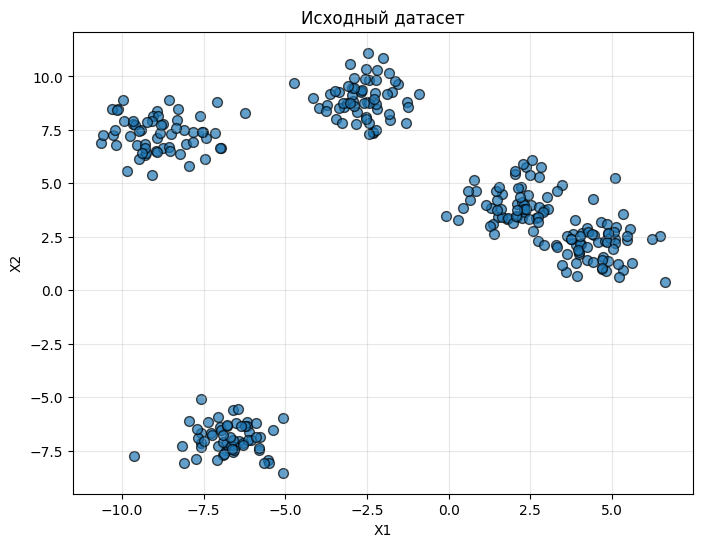

In [78]:
X, y = make_blobs(n_samples=300, centers=5, cluster_std=0.85, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, edgecolor='k', alpha=0.7)
plt.title('Исходный датасет')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, alpha=0.3)
plt.show()


## Метрики оценки качества кластеризации

Для подбора оптимального количества кластеров используем три внутренние метрики:

1. **Silhouette Score** - измеряет насколько похожи объекты внутри кластера по сравнению с объектами из других кластеров. Чем выше значение (максимум 1), тем лучше.

2. **Calinski-Harabasz Index (Variance Ratio Criterion)** - отношение межкластерной дисперсии к внутрикластерной дисперсии. Чем выше значение, тем лучше разделение кластеров.

3. **Davies-Bouldin Index** - среднее сходство между кластерами. Чем ниже значение (минимум 0), тем лучше разделение кластеров.


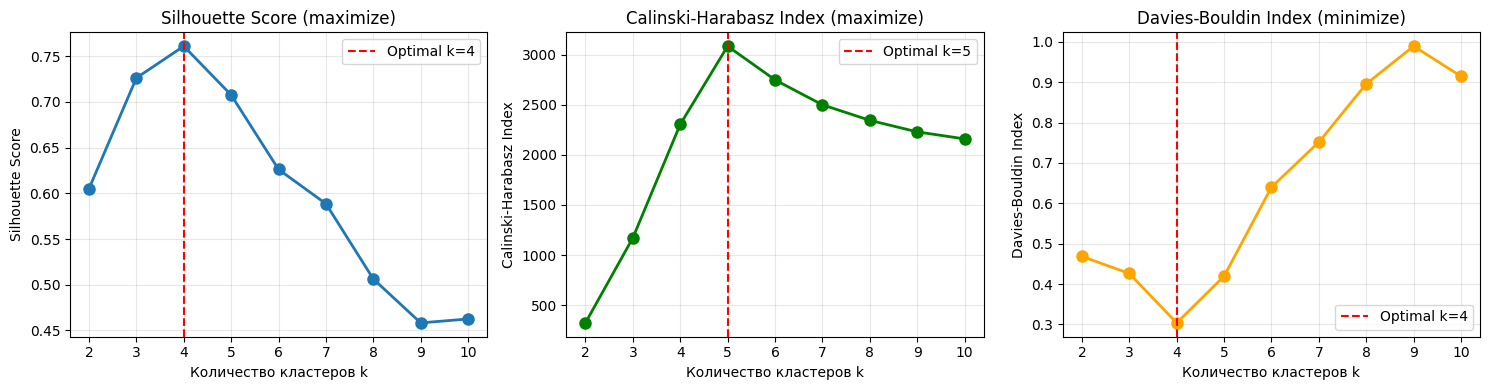

Результаты подбора оптимального k:
Silhouette Score: оптимальное k = 4, значение = 0.7608
Calinski-Harabasz Index: оптимальное k = 5, значение = 3085.3143
Davies-Bouldin Index: оптимальное k = 4, значение = 0.3038


In [79]:
k_range = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_scores.append(calinski_harabasz_score(X, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score (maximize)')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=k_range[np.argmax(silhouette_scores)], color='r', linestyle='--', 
                label=f'Optimal k={k_range[np.argmax(silhouette_scores)]}')
axes[0].legend()

axes[1].plot(k_range, calinski_scores, marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Количество кластеров k')
axes[1].set_ylabel('Calinski-Harabasz Index')
axes[1].set_title('Calinski-Harabasz Index (maximize)')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=k_range[np.argmax(calinski_scores)], color='r', linestyle='--',
                label=f'Optimal k={k_range[np.argmax(calinski_scores)]}')
axes[1].legend()

axes[2].plot(k_range, davies_bouldin_scores, marker='o', linewidth=2, markersize=8, color='orange')
axes[2].set_xlabel('Количество кластеров k')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (minimize)')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=k_range[np.argmin(davies_bouldin_scores)], color='r', linestyle='--',
                label=f'Optimal k={k_range[np.argmin(davies_bouldin_scores)]}')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Результаты подбора оптимального k:")
print(f"Silhouette Score: оптимальное k = {k_range[np.argmax(silhouette_scores)]}, значение = {max(silhouette_scores):.4f}")
print(f"Calinski-Harabasz Index: оптимальное k = {k_range[np.argmax(calinski_scores)]}, значение = {max(calinski_scores):.4f}")
print(f"Davies-Bouldin Index: оптимальное k = {k_range[np.argmin(davies_bouldin_scores)]}, значение = {min(davies_bouldin_scores):.4f}")



Оптимальные значения k по метрикам:
  Silhouette Score: k = 4
  Calinski-Harabasz Index: k = 5
  Davies-Bouldin Index: k = 4


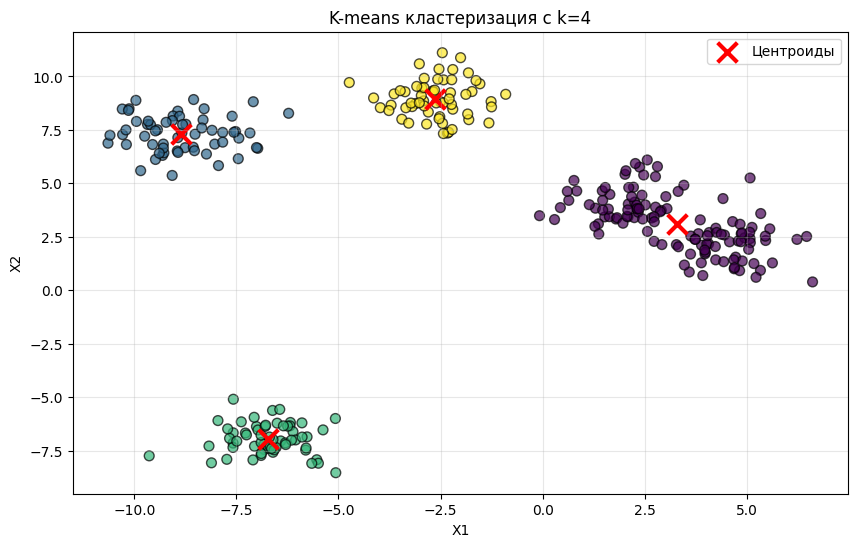


Финальное значение оптимального k: 4
Количество итераций: 2
Inertia (within-cluster sum of squares): 713.3890


In [80]:
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_scores)]
optimal_k_davies = k_range[np.argmin(davies_bouldin_scores)]

print(f"\nОптимальные значения k по метрикам:")
print(f"  Silhouette Score: k = {optimal_k_silhouette}")
print(f"  Calinski-Harabasz Index: k = {optimal_k_calinski}")
print(f"  Davies-Bouldin Index: k = {optimal_k_davies}")

optimal_k = optimal_k_silhouette

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_optimal = kmeans_optimal.fit_predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_optimal, s=50, edgecolor='k', alpha=0.7, cmap='viridis')
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1], 
            marker='x', s=200, linewidths=3, color='red', label='Центроиды')
plt.title(f'K-means кластеризация с k={optimal_k}')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nФинальное значение оптимального k: {optimal_k}")
print(f"Количество итераций: {kmeans_optimal.n_iter_}")
print(f"Inertia (within-cluster sum of squares): {kmeans_optimal.inertia_:.4f}")


# 2

In [81]:
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']
linkage_metrics = {
    'ward': ['euclidean'],  # ward работает только с euclidean
    'complete': metrics,
    'average': metrics,
    'single': metrics
}

best_score = -1
best_params = None
best_labels = None
results = []

for linkage_method in linkage_methods:
    for metric in linkage_metrics[linkage_method]:
        try:
            clustering = AgglomerativeClustering(
                n_clusters=optimal_k, 
                linkage=linkage_method,
                metric=metric
            )
            labels = clustering.fit_predict(X)
            score = silhouette_score(X, labels)
            results.append({
                'linkage': linkage_method,
                'metric': metric,
                'score': score
            })
            
            if score > best_score:
                best_score = score
                best_params = {'linkage': linkage_method, 'metric': metric}
                best_labels = labels
        except Exception as e:
            print(f"Ошибка для {linkage_method}, {metric}: {e}")

results_df = pd.DataFrame(results).sort_values('score', ascending=False)
print("Топ-5 комбинаций параметров:")
print(results_df.head())
print(f"\nЛучшие параметры: {best_params}, Score: {best_score:.4f}")


Топ-5 комбинаций параметров:
    linkage     metric     score
0      ward  euclidean  0.760772
1  complete  euclidean  0.760772
5   average  manhattan  0.760772
4   average  euclidean  0.760772
8    single  manhattan  0.760772

Лучшие параметры: {'linkage': 'ward', 'metric': 'euclidean'}, Score: 0.7608


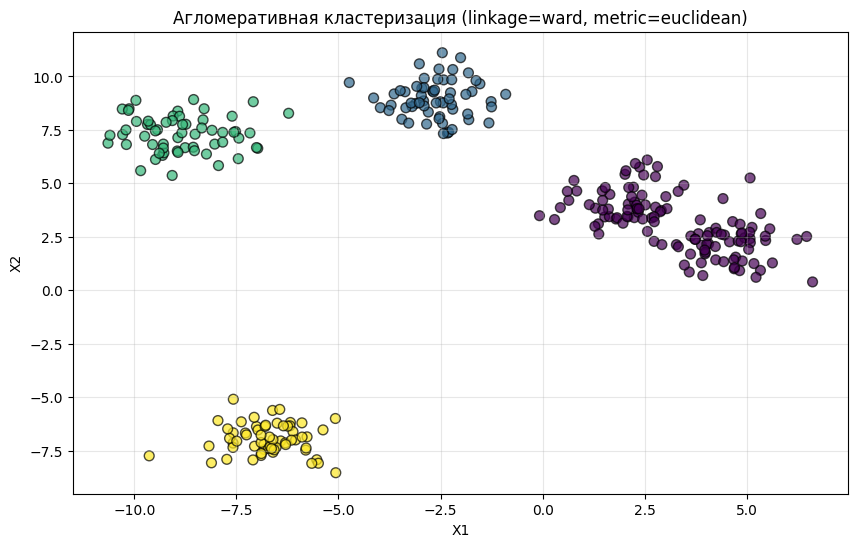

In [82]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=best_labels, s=50, edgecolor='k', alpha=0.7, cmap='viridis')
plt.title(f'Агломеративная кластеризация (linkage={best_params["linkage"]}, metric={best_params["metric"]})')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, alpha=0.3)
plt.show()


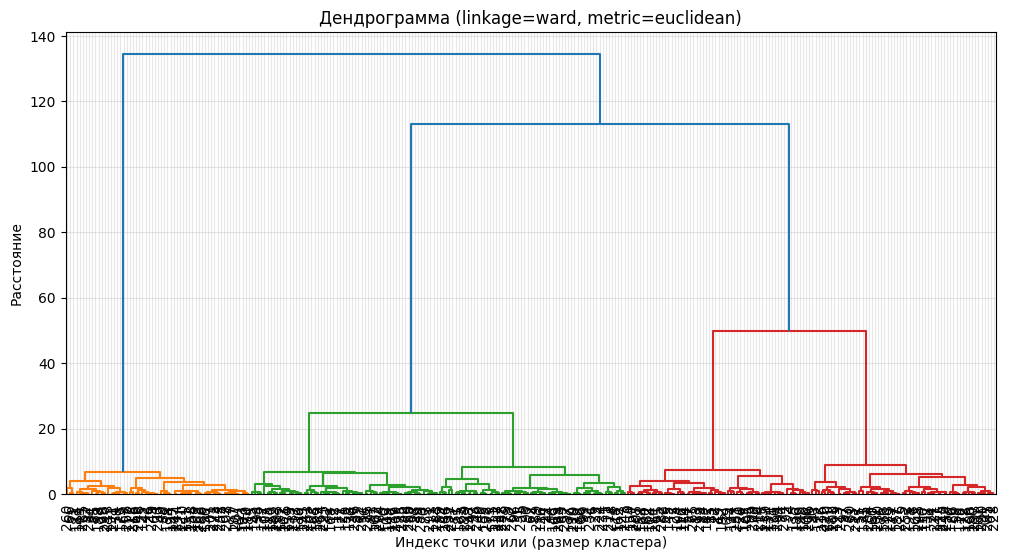

In [83]:
linkage_matrix = linkage(X, method=best_params['linkage'], metric=best_params['metric'])

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=10, leaf_rotation=90, leaf_font_size=10)
plt.title(f'Дендрограмма (linkage={best_params["linkage"]}, metric={best_params["metric"]})')
plt.xlabel('Индекс точки или (размер кластера)')
plt.ylabel('Расстояние')
plt.grid(True, alpha=0.3)
plt.show()


# 3

Для преобразования матрицы расстояний в матрицу сходства используем функцию:

$$S(x_i, x_j) = \frac{1}{1 + d(x_i, x_j)}$$

Эта функция удовлетворяет всем требованиям:
- $S(x_i, x_i) = \frac{1}{1 + 0} = 1$ (диагональные элементы равны 1)
- $0 \leq S(x_i, x_j) < 1$ для $x_i \neq x_j$ (так как $d(x_i, x_j) > 0$)
- $S(x_i, x_j) = S(x_j, x_i)$ (симметричность, так как $d(x_i, x_j) = d(x_j, x_i)$)


In [84]:
distance_matrix = pairwise_distances(X, metric='euclidean')

print(f"Размерность матрицы расстояний: {distance_matrix.shape}")
print(f"Минимальное расстояние (не считая диагональ): {distance_matrix[distance_matrix > 0].min():.4f}")
print(f"Максимальное расстояние: {distance_matrix.max():.4f}")
print(f"Среднее расстояние: {distance_matrix[distance_matrix > 0].mean():.4f}")
print(f"\nМатрица симметрична: {np.allclose(distance_matrix, distance_matrix.T)}")
print(f"Диагональные элементы нулевые: {np.allclose(np.diag(distance_matrix), 0)}")


Размерность матрицы расстояний: (300, 300)
Минимальное расстояние (не считая диагональ): 0.0030
Максимальное расстояние: 20.1783
Среднее расстояние: 9.2885

Матрица симметрична: True
Диагональные элементы нулевые: True


In [85]:
similarity_matrix = 1 / (1 + distance_matrix)
np.fill_diagonal(similarity_matrix, 1.0)  # Явно устанавливаем 1 для диагонали (на случай численных погрешностей)

print(f"Размерность матрицы сходства: {similarity_matrix.shape}")
print(f"Минимальное сходство (не считая диагональ): {similarity_matrix[similarity_matrix < 1].min():.6f}")
print(f"Максимальное сходство: {similarity_matrix.max():.4f}")
print(f"Среднее сходство: {similarity_matrix[similarity_matrix < 1].mean():.6f}")
print(f"\nДиагональные элементы равны 1: {np.allclose(np.diag(similarity_matrix), 1.0)}")
print(f"Все элементы в [0, 1]: {(similarity_matrix >= 0).all() and (similarity_matrix <= 1).all()}")
print(f"Матрица симметрична: {np.allclose(similarity_matrix, similarity_matrix.T)}")


Размерность матрицы сходства: (300, 300)
Минимальное сходство (не считая диагональ): 0.047218
Максимальное сходство: 1.0000
Среднее сходство: 0.168700

Диагональные элементы равны 1: True
Все элементы в [0, 1]: True
Матрица симметрична: True


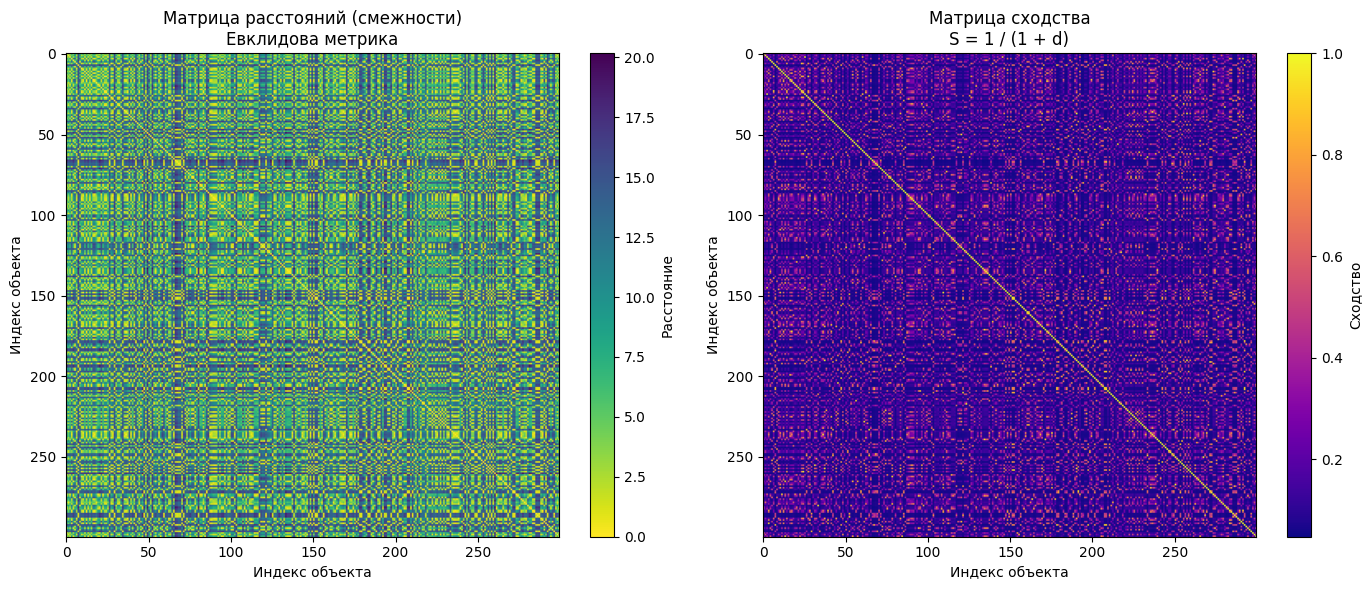

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(distance_matrix, cmap='viridis_r', aspect='auto')
axes[0].set_title('Матрица расстояний (смежности)\nЕвклидова метрика', fontsize=12)
axes[0].set_xlabel('Индекс объекта')
axes[0].set_ylabel('Индекс объекта')
plt.colorbar(im1, ax=axes[0], label='Расстояние')

im2 = axes[1].imshow(similarity_matrix, cmap='plasma', aspect='auto')
axes[1].set_title('Матрица сходства\nS = 1 / (1 + d)', fontsize=12)
axes[1].set_xlabel('Индекс объекта')
axes[1].set_ylabel('Индекс объекта')
plt.colorbar(im2, ax=axes[1], label='Сходство')

plt.tight_layout()
plt.show()


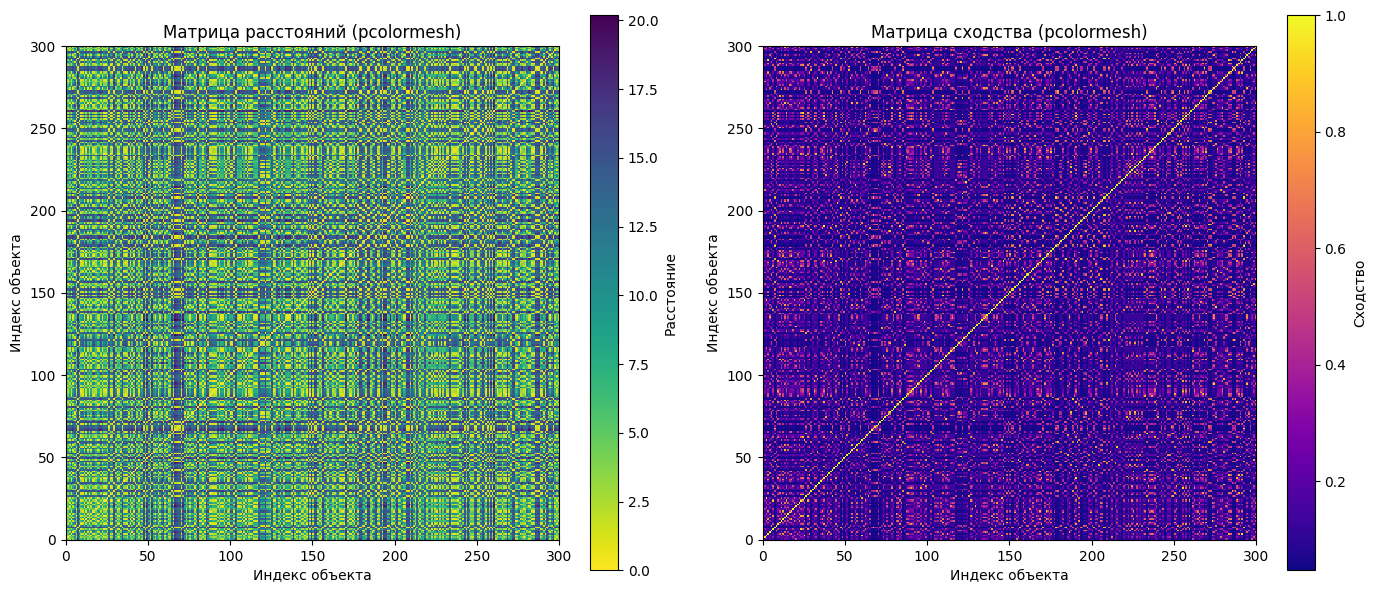

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(distance_matrix.shape[1] + 1)
y = np.arange(distance_matrix.shape[0] + 1)
mesh1 = axes[0].pcolormesh(x, y, distance_matrix, cmap='viridis_r', shading='flat')
axes[0].set_title('Матрица расстояний (pcolormesh)', fontsize=12)
axes[0].set_xlabel('Индекс объекта')
axes[0].set_ylabel('Индекс объекта')
axes[0].set_aspect('equal')
plt.colorbar(mesh1, ax=axes[0], label='Расстояние')

mesh2 = axes[1].pcolormesh(x, y, similarity_matrix, cmap='plasma', shading='flat')
axes[1].set_title('Матрица сходства (pcolormesh)', fontsize=12)
axes[1].set_xlabel('Индекс объекта')
axes[1].set_ylabel('Индекс объекта')
axes[1].set_aspect('equal')
plt.colorbar(mesh2, ax=axes[1], label='Сходство')

plt.tight_layout()
plt.show()


# 4

In [88]:
data = pd.read_csv("toy_galaxies.csv")
print(f"Размерность данных: {data.shape}")
print(f"\nПервые 5 строк:")
print(data.head())

if 'label' in data.columns:
    print(f"\nКоличество уникальных меток: {data['label'].nunique()}")
    print(f"Распределение меток:\n{data['label'].value_counts().sort_index()}")


Размерность данных: (5512, 4)

Первые 5 строк:
           x          y           z  label
0 -35.283431 -21.779673 -113.964124    1.0
1 -35.603636 -18.430420 -113.298009    1.0
2 -34.202934 -22.362906 -106.979709    1.0
3 -34.035994 -19.655401 -106.702395    1.0
4 -35.365589 -22.747940 -110.307321    1.0

Количество уникальных меток: 100
Распределение меток:
label
1.0      189
2.0       66
3.0       29
4.0       35
5.0       14
        ... 
96.0      71
97.0      51
98.0      34
99.0      38
100.0      3
Name: count, Length: 100, dtype: int64


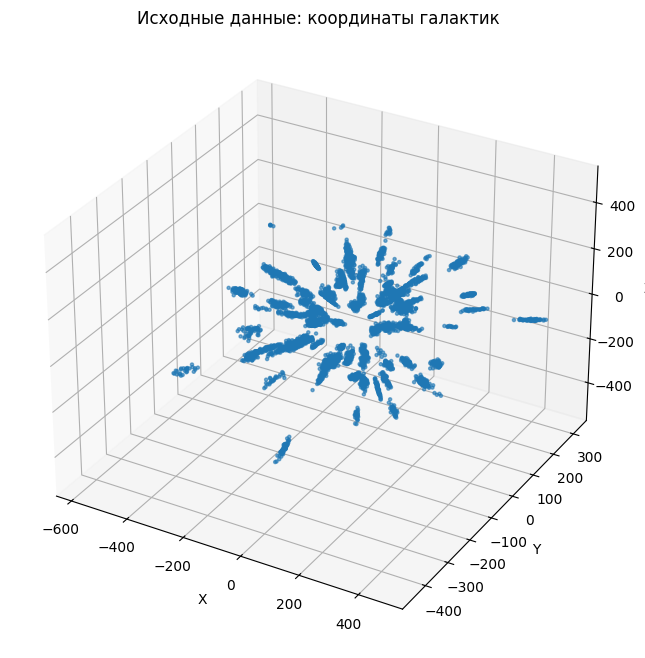

In [89]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data.x, data.y, data.z, marker='.', s=20, alpha=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Исходные данные: координаты галактик')
plt.show()


In [90]:
def plot_galaxies(data, cluster, title="Кластеризация галактик"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    labels = cluster.labels_
    colors = labels if labels.min() >= 0 else labels + 1  # Сдвигаем -1 в 0 для визуализации
    
    scatter = ax.scatter(data.x, data.y, data.z, marker='.', s=20, c=colors, 
                        cmap='tab20', alpha=0.7, edgecolors='none')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    plt.colorbar(scatter, ax=ax, label='Кластер', pad=0.1)
    plt.show()
    
    if 'label' in data.columns:
        ari_score = ari(data.label, labels)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f'ARI = {ari_score:.4f}')
        print(f'Количество кластеров: {n_clusters}')
        print(f'Точек шума: {n_noise}')
        return ari_score
    return None


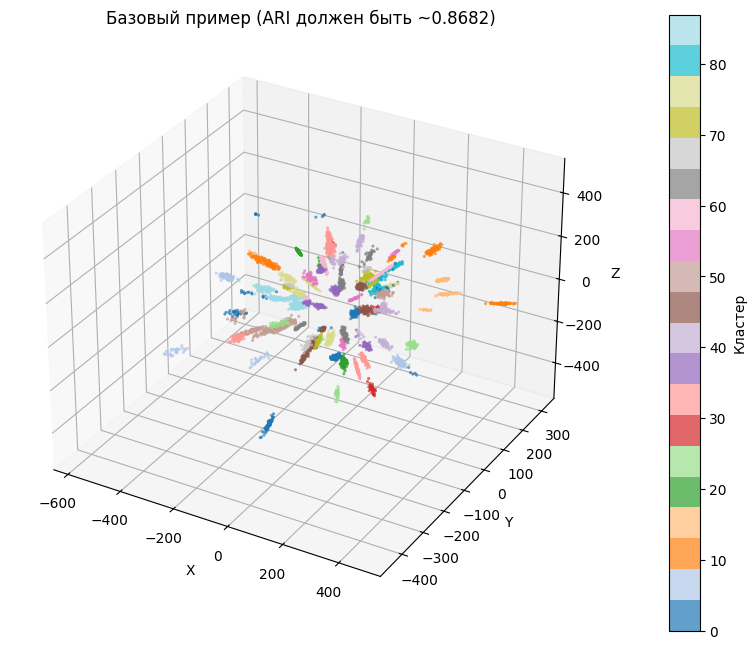

ARI = 0.8726
Количество кластеров: 87
Точек шума: 55


In [91]:
X_galaxies = data[['x', 'y', 'z']].to_numpy()

cluster_baseline = hdbscan.HDBSCAN(
    metric="euclidean",
    min_cluster_size=9,
    algorithm="generic",
    alpha=0.8,
    cluster_selection_method='eom'
)
cluster_baseline.fit(X_galaxies)
ari_baseline = plot_galaxies(data, cluster_baseline, "Базовый пример (ARI должен быть ~0.8682)")


In [92]:
min_cluster_sizes = [5, 7, 9, 11, 13, 15]
metrics_list = ['euclidean', 'manhattan', 'cosine']
alphas = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
cluster_selection_methods = ['eom', 'leaf']

best_ari = -1
best_params = None
best_cluster = None
results_list = []

print("Перебираем параметры HDBSCAN...")

for min_cluster_size in min_cluster_sizes:
    for metric in metrics_list:
        for alpha in alphas:
            for cluster_selection_method in cluster_selection_methods:
                try:
                    cluster = hdbscan.HDBSCAN(
                        metric=metric,
                        min_cluster_size=min_cluster_size,
                        min_samples=min_cluster_size,
                        algorithm="generic",
                        alpha=alpha,
                        cluster_selection_method=cluster_selection_method
                    )
                    cluster.fit(X_galaxies)
                    
                    if 'label' in data.columns:
                        ari_score = ari(data.label, cluster.labels_)
                        results_list.append({
                            'min_cluster_size': min_cluster_size,
                            'metric': metric,
                            'alpha': alpha,
                            'cluster_selection_method': cluster_selection_method,
                            'ari': ari_score,
                            'n_clusters': len(set(cluster.labels_)) - (1 if -1 in cluster.labels_ else 0),
                            'n_noise': list(cluster.labels_).count(-1)
                        })
                        
                        if ari_score > best_ari:
                            best_ari = ari_score
                            best_params = {
                                'min_cluster_size': min_cluster_size,
                                'metric': metric,
                                'alpha': alpha,
                                'cluster_selection_method': cluster_selection_method
                            }
                            best_cluster = cluster
                            
                        if ari_score >= 0.900:
                            print(f"Достигнут целевой ARI >= 0.900!")
                            print(f"  Параметры: {best_params}")
                            print(f"  ARI: {ari_score:.4f}")
                            break
                except Exception as e:
                    continue
            if best_ari >= 0.900:
                break
        if best_ari >= 0.900:
            break
    if best_ari >= 0.900:
        break

print(f"\nПроверено комбинаций: {len(results_list)}")


Перебираем параметры HDBSCAN...
Достигнут целевой ARI >= 0.900!
  Параметры: {'min_cluster_size': 5, 'metric': 'euclidean', 'alpha': 0.7, 'cluster_selection_method': 'eom'}
  ARI: 0.9175

Проверено комбинаций: 5


In [93]:
if results_list:
    results_df = pd.DataFrame(results_list).sort_values('ari', ascending=False)
    print("\nТоп-10 комбинаций параметров:")
    print(results_df.head(10).to_string(index=False))
    
    if best_params is not None:
        print(f"\nЛучшие параметры:")
        print(f"  min_cluster_size: {best_params['min_cluster_size']}")
        print(f"  metric: {best_params['metric']}")
        print(f"  alpha: {best_params['alpha']}")
        print(f"  cluster_selection_method: {best_params['cluster_selection_method']}")
        print(f"  ARI: {best_ari:.4f}")
        
        if best_ari >= 0.900:
            print(f"Цель достигнута! ARI >= 0.900")
        else:
            print(f"\n✗ Цель не достигнута. Максимальный ARI: {best_ari:.4f}")
            print("Попробуем более тонкую настройку...")
    else:
        print("Не удалось найти подходящие параметры.")
        best_cluster = cluster_baseline
        best_params = {'min_cluster_size': 9, 'metric': 'euclidean', 'alpha': 0.8, 
                       'cluster_selection_method': 'eom'}
        if 'label' in data.columns:
            best_ari = ari(data.label, cluster_baseline.labels_)
        else:
            best_ari = ari_baseline if ari_baseline is not None else 0
else:
    print("Результаты не получены. Используем базовую модель.")
    best_cluster = cluster_baseline
    best_params = {'min_cluster_size': 9, 'metric': 'euclidean', 'alpha': 0.8, 
                   'cluster_selection_method': 'eom'}
    if 'label' in data.columns:
        best_ari = ari(data.label, cluster_baseline.labels_)
    else:
        best_ari = ari_baseline if ari_baseline is not None else 0



Топ-10 комбинаций параметров:
 min_cluster_size    metric  alpha cluster_selection_method      ari  n_clusters  n_noise
                5 euclidean    0.7                      eom 0.917543          97       41
                5 euclidean    0.6                      eom 0.876326          96       16
                5 euclidean    0.5                      eom 0.871617         103       33
                5 euclidean    0.5                     leaf 0.025702         405     1890
                5 euclidean    0.6                     leaf 0.022395         372     2061

Лучшие параметры:
  min_cluster_size: 5
  metric: euclidean
  alpha: 0.7
  cluster_selection_method: eom
  ARI: 0.9175
Цель достигнута! ARI >= 0.900


In [94]:
if 'best_ari' in locals() and best_ari < 0.900 and best_params is not None:
    print("\nПробуем более тонкую настройку параметров...")
    
    best_min_size = best_params['min_cluster_size'] if best_params else 9
    best_metric = best_params['metric'] if best_params else 'euclidean'
    best_alpha = best_params['alpha'] if best_params else 0.8
    
    fine_min_sizes = range(max(3, best_min_size - 3), best_min_size + 4)
    fine_alphas = np.arange(max(0.3, best_alpha - 0.2), min(1.5, best_alpha + 0.3), 0.1)
    
    for min_size in fine_min_sizes:
        for alpha in fine_alphas:
            for method in ['eom', 'leaf']:
                try:
                    cluster = hdbscan.HDBSCAN(
                        metric=best_metric,
                        min_cluster_size=min_size,
                        min_samples=max(1, min_size - 2),
                        algorithm="generic",
                        alpha=alpha,
                        cluster_selection_method=method
                    )
                    cluster.fit(X_galaxies)
                    
                    if 'label' in data.columns:
                        ari_score = ari(data.label, cluster.labels_)
                        if ari_score > best_ari:
                            best_ari = ari_score
                            best_params = {
                                'min_cluster_size': min_size,
                                'metric': best_metric,
                                'alpha': alpha,
                                'cluster_selection_method': method
                            }
                            best_cluster = cluster
                            
                        if ari_score >= 0.900:
                            print(f"✓ Достигнут целевой ARI >= 0.900!")
                            print(f"  Параметры: min_cluster_size={min_size}, alpha={alpha:.2f}, method={method}")
                            print(f"  ARI: {ari_score:.4f}")
                            break
                except:
                    continue
            if best_ari >= 0.900:
                break
        if best_ari >= 0.900:
            break
    
    print(f"\nФинальный результат после тонкой настройки:")
    print(f"  Параметры: {best_params}")
    print(f"  ARI: {best_ari:.4f}")


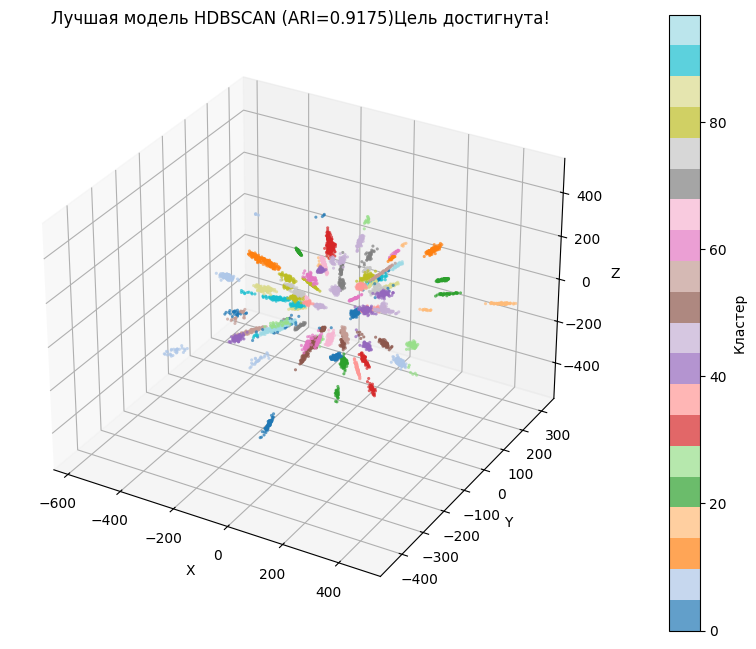

ARI = 0.9175
Количество кластеров: 97
Точек шума: 41

Итоговые параметры лучшей модели:
  min_cluster_size: 5
  metric: euclidean
  alpha: 0.7
  cluster_selection_method: eom
  ARI: 0.9175


In [95]:
if best_cluster is not None and best_params is not None:
    if 'best_ari' in locals():
        title = f"Лучшая модель HDBSCAN (ARI={best_ari:.4f})"
        if best_ari >= 0.900:
            title += "Цель достигнута!"
    else:
        title = "Лучшая модель HDBSCAN"
    plot_galaxies(data, best_cluster, title)
    
    print(f"\nИтоговые параметры лучшей модели:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    if 'best_ari' in locals():
        print(f"  ARI: {best_ari:.4f}")
else:
    print("Лучшая модель не найдена")
